<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/SVM_con_datos_industriales_comparado_con_Random_Forest_Arboles_regresi%C3%B3n_log%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Contexto

El conjunto de datos que se utilzia en este caso de estudio, representa un proceso de manufactura industrial, la idea es utilizarlo como fuente para construir, evaluar y comparar modelos de clasificación sobre la calidad de fabricación.

Es un conjunto de datos de *3000* registros, *10* variables independiente y todas ellas son numéricas.  Las variables independientes son las siguientes:

* *temperatura*. es el promedio registrada durante el proceso de fabricación. Influye directamente en la calidad del producto, especialmente en procesos de fundición, tratamiento térmico o moldeo se midde en grados centpigrados °C,
* *presion* es la presión de operación aplicada durante el proceso productivo. Variaciones importantes pueden afectar la estabilidad del proceso, medido en *kPa*,
* *velocidad_linea*  es la velocidad de desplazamiento de la línea de producción o de la banda transportadora. Velocidades excesivas o muy bajas pueden modificar la calidad final, tiempo en minutos,                               |
* *humedad* es la humedad relativa del ambiente de producción. En diversos procesos industriales puede influir sobre el secado, adherencia o estabilidad del material,
* *vibracion* es el nivel promedio de vibración de la maquinaria durante la fabricación;  valores elevados pueden indicar desgaste mecánico o desalineación de equipos, mm/s,
* *consumo_energia* es el consumo energético registrado durante la fabricación del lote. Refleja indirectamente la carga de trabajo y la eficiencia del proceso, medido en kWh, * *experiencia_operador* Los años de experiencia del operador responsable del proceso. Se considera un factor humano que puede influir en la estabilidad y calidad de la producción,
* *mantenimiento_dias* es el número de días transcurridos desde el último mantenimiento preventivo de la maquinaria. Conforme aumenta este valor puede incrementarse la probabilidad de fallas, medido en dias,
* *espesor_material* es el espesor promedio del material procesado. Es una característica física del producto que puede afectar la resistencia y uniformidad del proceso, medido en mm,
* *dureza_material* la dureza del material medida mediante un ensayo de laboratorio. Representa una propiedad mecánica relacionada con la resistencia del producto. Medido en escala de dureza HB,

La variable dependiente es calidad, la cual puede tomar tres categorías:

* *Alta*: el producto cumple satisfactoriamente con las especificaciones de calidad.
* *Media*: el producto presenta pequeñas desviaciones respecto a las especificaciones, aunque sigue siendo aceptable.
* *Baja*: el producto no cumple con los criterios establecidos y requiere re-trabajo o es rechazado.

El caso de estudio se puede ver de manera digital en el servicio *google collab* en https://colab.research.google.com/drive/1GkU0zg-x2FHtDk_Yn6SQxP4zIK9if8ci?usp=sharing  .

De igual manera, el caso de studio puede descargarse y verificarse en https://github.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/SVM_con_datos_industriales_comparado_con_Random_Forest_Arboles_regresi%C3%B3n_log%C3%ADstica.ipynb .


Los datos para su descarga se encuentran en https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_industrial_clasificacion_multinomial_3000_4decimales.csv .


Las funciones de Python previamente preparadas para la adecuada ejecución de este caso de estudio y de igual manera descargables y verificables, se encuentran en el servicio github.com en https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20implementar%20y%20evaluar%20SVR%20kernel%20lineal%20polinomial%20radial%20y%20RLM%20con%20datos%20calidad%20de%20vino.py .



# Objetivo

Crear, comparar y evaluar modelos de clasificación *SVM* con *kernels* lineal, polinomial y radial con datos de calidad en procesos industriales.

La comparación y evaluación de los modelos se hará valorando la calidad predictiva a través de los estadísticos que se extraen de las matrices de confusión de las predicciones de los datos de validación.

Los modelos *SVM* serán comparados y valorados contra otros modelos de clasifiación como *Random Forest*, árboles de clasificación y regresión logística multinomial.


Los datos se particionan con el *70%* para datos de entrenamiejto y *30%* para datos de validación.

Los datos de entrenamiento y de validación son estandarizados con los mismos criterios para evitar y disminuir la fuga de datos.

# Descripción

## Cargar librerías


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.preprocessing import PolynomialFeatures
# from sklearn.linear_model import LinearRegression
# from sklearn.linear_model import LassoCV
# from sklearn.linear_model import RidgeCV
# from sklearn.metrics import ( mean_squared_error,
#    mean_absolute_error,  r2_score )

# from scipy.stats import shapiro
# from scipy.stats import kstest
# from statsmodels.stats.diagnostic import het_breuschpagan
# from statsmodels.stats.stattools import durbin_watson
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from statsmodels.stats.diagnostic import linear_reset
# import statsmodels.api as sm

# Para validar posutalados
# from statsmodels.stats.outliers_influence import (
#    variance_inflation_factor)
# from statsmodels.stats.diagnostic import (het_breuschpagan,
#    linear_reset)
# from statsmodels.stats.stattools import ( durbin_watson)
# from scipy.stats import ( shapiro)
# from scipy.stats import shapiro
# from scipy.stats import kstest
# from scipy.stats import anderson
# from sklearn.linear_model import (  LassoCV)
# from sklearn.linear_model import (  RidgeCV)
# from sklearn.preprocessing import (PolynomialFeatures)
# from sklearn.svm import SVR # Para modelos SVR

from sklearn.svm import LinearSVC # Krnel lineal
from sklearn.svm import SVC # Para SVM
# Para arboles de clasificación y bosques aleatorios
from sklearn.tree import DecisionTreeClassifier # Árbol de clasificación
from sklearn.ensemble import RandomForestClassifier # Bosque aleatorio de clasificación
from sklearn.tree import plot_tree # Visualización del árbol
from sklearn.tree import export_text # Exportar reglas del árbol

from sklearn.linear_model import LogisticRegression # Reg Logistica
from sklearn.utils import resample # Muestras y submuestras

## Cargar funciones


In [21]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/Python%20NoteBooks/funciones/Funciones%20para%20implementar%20y%20evaluar%20SVR%20kernel%20lineal%20polinomial%20radial%20y%20RLM%20con%20datos%20calidad%20de%20vino.py"
import requests

exec(requests.get(url).text)

## Cagar datos

Se cargan los datos con la función *f_cargar_datos()* y se visualizan los primeros y últimos registros con las primeras y últimas cuatros variables con la función *f_visualizar_head_tail_reducido()*; se muestran los datos con dos posiciones decimales en las variables numéricas haciendo uso de *f_redondear()*.

In [22]:
url = "https://raw.githubusercontent.com/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/refs/heads/main/datos/dataset_industrial_clasificacion_multinomial_3000_4decimales.csv"
datos = f_cargar_datos(url)
f_visualizar_head_tail_reducido(f_redondear(datos))

,temperatura,presion,velocidad_linea,humedad,...,mantenimiento_dias,espesor_material,dureza_material,calidad
0,87.45,194.36,68.34,83.95,...,46.35,10.6,445.85,Alta
1,145.07,215.44,25.51,56.78,...,28.87,7.55,110.52,Baja
2,123.2,122.58,88.52,70.74,...,47.34,1.78,464.4,Media
3,109.87,186.23,65.18,50.52,...,4.41,13.86,222.3,Media
4,65.6,177.2,24.15,64.1,...,11.5,14.72,303.29,Alta
5,65.6,221.58,96.61,43.84,...,33.09,7.03,152.92,Baja
6,...,...,...,...,...,...,...,...,...
7,63.17,92.28,36.65,88.43,...,9.27,6.3,207.73,Baja
8,136.53,196.35,56.34,20.33,...,54.8,5.6,480.91,Media
9,65.73,165.55,24.88,81.16,...,25.71,7.72,399.13,Alta


## Estadísticos descriptivos

Se muestran los estadísticos descriptivos de los datos.

In [23]:
f_describir_datos(datos)

{'describe':                        count      mean       std       min       25%  \
 temperatura           3000.0   99.9893   29.1656   50.0012   74.5806   
 presion               3000.0  164.0335   48.8620   80.0052  121.7737   
 velocidad_linea       3000.0   53.8653   25.7026   10.0217   31.7321   
 humedad               3000.0   55.1806   20.1776   20.0037   37.8167   
 vibracion             3000.0    4.9864    2.9045    0.0120    2.4397   
 consumo_energia       3000.0  553.6965  258.1449  100.2272  333.3603   
 experiencia_operador  3000.0   10.7539    5.4855    1.0116    6.1581   
 mantenimiento_dias    3000.0   30.6498   17.3631    0.0029   15.6203   
 espesor_material      3000.0    7.9451    3.9999    1.0015    4.5030   
 dureza_material       3000.0  295.4396  113.7782  100.0501  197.3827   
 
                            50%       75%       max  
 temperatura           100.5353  125.4334  149.9718  
 presion               162.9666  205.5603  249.9248  
 velocidad_linea     

## Frecuencia de clases

De las variables categóricas y específicamente la variable dependiente *calidad* se muestra mediante el diagrama de barra, la frecuencia de su valor con el *33%* para cada clase.

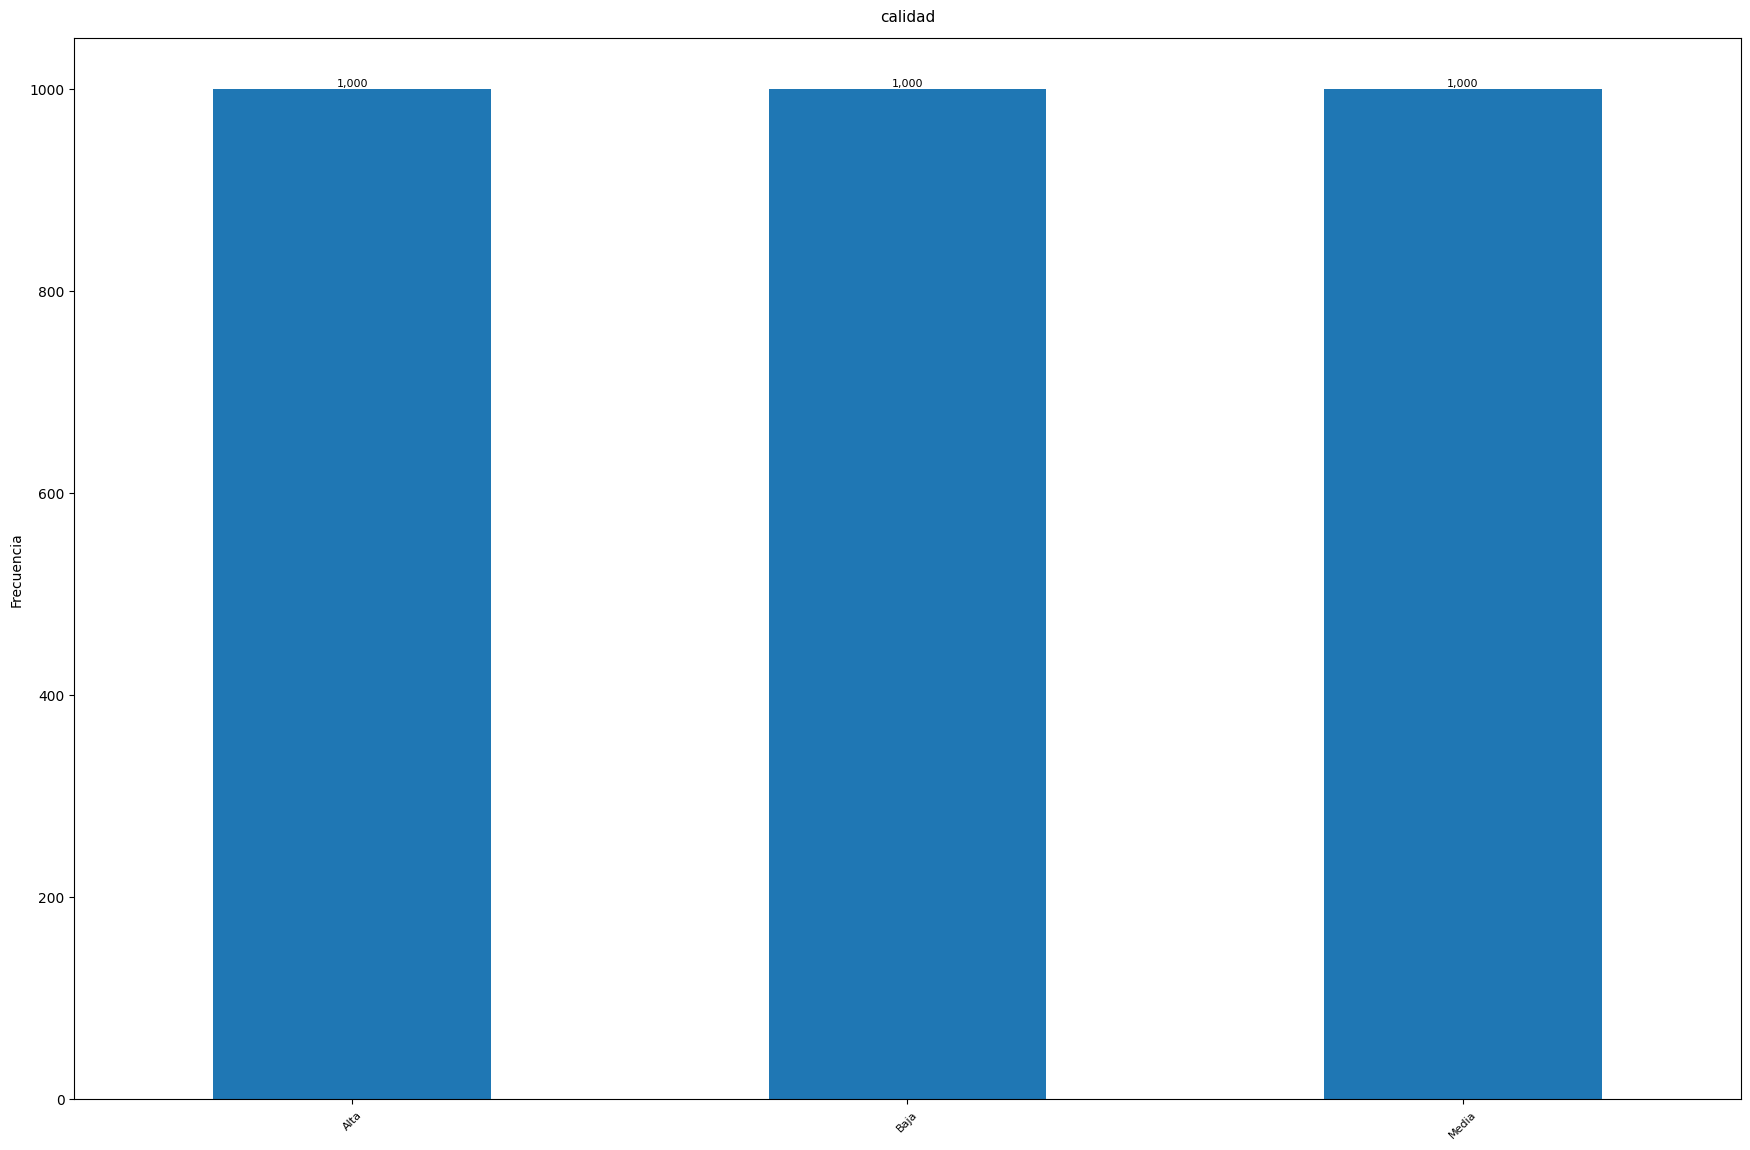

In [24]:
f_frecuencias_clases(datos)

# Desarrollo


## Datos de entrenamiento y datos de validación

Se muestran los datos de entrenamiento y validación a dos posiciones numéricas.

In [25]:
particiones = f_particionar_datos(datos)
datos_entrenamiento = particiones["datos_entrenamiento"]
datos_validacion = particiones["datos_validacion"]
f_visualizar_head_tail_reducido(f_redondear(datos_entrenamiento))

,temperatura,presion,velocidad_linea,humedad,...,mantenimiento_dias,espesor_material,dureza_material,calidad
0,109.03,182.16,68.84,51.48,...,5.65,11.77,302.77,Alta
1,129.46,246.44,73.92,36.17,...,39.7,4.92,300.33,Baja
2,76.56,104.36,72.33,26.59,...,57.75,8.06,372.83,Baja
3,92.52,241.88,16.76,68.43,...,34.69,5.9,339.78,Baja
4,107.84,189.69,99.12,69.01,...,2.38,7.29,169.86,Alta
5,108.3,122.7,67.9,59.09,...,26.74,2.78,457.99,Media
6,...,...,...,...,...,...,...,...,...
7,92.37,232.56,90.47,69.36,...,45.27,8.03,492.72,Baja
8,135.76,165.77,25.36,72.88,...,32.82,11.59,384.29,Alta
9,116.79,183.76,10.02,70.57,...,21.02,2.04,475.44,Alta


Datos de validación:


In [26]:
f_visualizar_head_tail_reducido(f_redondear(datos_validacion))

,temperatura,presion,velocidad_linea,humedad,...,mantenimiento_dias,espesor_material,dureza_material,calidad
0,110.96,232.21,56.1,44.86,...,23.61,10.98,482.93,Media
1,77.23,172.9,52.77,27.6,...,12.6,12.49,424.32,Media
2,146.99,128.9,83.6,45.69,...,23.94,12.46,223.31,Media
3,77.02,129.25,70.62,32.2,...,3.37,7.08,270.03,Media
4,85.07,82.75,20.78,53.4,...,12.61,2.21,232.43,Baja
5,63.07,135.99,17.67,62.69,...,18.61,10.01,435.42,Media
6,...,...,...,...,...,...,...,...,...
7,71.67,209.2,10.75,83.42,...,16.73,1.3,170.61,Media
8,73.19,238.87,70.46,48.69,...,35.52,2.41,116.24,Baja
9,110.11,194.58,66.42,54.87,...,2.59,5.51,469.66,Media


## Estandrización de datos

La función f_estandarizar_train_transf_valid(), recibe los datos ya particionados, calcula medias y desviaciones únicamente con la los datos de entrenamiento, estandariza estos y aplica exactamente la misma transformación a los datos de validación y devuelve ambos conjuntos listos para construir modelos de clasificación.

Se muestran las datos de entrenamiento y validación estandarizados a dos posiciones numéricas.



In [27]:
resultado = f_estandarizar_train_transf_valid(
    datos_entrenamiento, datos_validacion, "calidad")

datos_entrenamiento_std = (resultado["datos_entrenamiento"])

datos_validacion_std = (resultado["datos_validacion"])
f_visualizar_head_tail_reducido(f_redondear(datos_entrenamiento_std))

,temperatura,presion,velocidad_linea,humedad,...,mantenimiento_dias,espesor_material,dureza_material,calidad
0,0.31,0.38,0.57,-0.18,...,-1.43,0.95,0.05,Alta
1,1.0,1.7,0.76,-0.93,...,0.54,-0.77,0.03,Baja
2,-0.8,-1.22,0.7,-1.4,...,1.58,0.02,0.68,Baja
3,-0.26,1.6,-1.44,0.65,...,0.25,-0.53,0.38,Baja
4,0.27,0.53,1.74,0.68,...,-1.62,-0.18,-1.13,Alta
5,0.28,-0.84,0.53,0.19,...,-0.21,-1.31,1.43,Media
6,...,...,...,...,...,...,...,...,...
7,-0.26,1.41,1.4,0.7,...,0.86,0.01,1.74,Baja
8,1.22,0.04,-1.11,0.87,...,0.14,0.91,0.78,Alta
9,0.57,0.41,-1.7,0.76,...,-0.54,-1.5,1.59,Alta


Datos de validación estandarizados:


In [28]:
f_visualizar_head_tail_reducido(f_redondear(datos_validacion_std))

,temperatura,presion,velocidad_linea,humedad,...,mantenimiento_dias,espesor_material,dureza_material,calidad
0,0.37,1.41,0.08,-0.51,...,-0.39,0.75,1.65,Media
1,-0.78,0.19,-0.05,-1.35,...,-1.03,1.13,1.13,Media
2,1.6,-0.71,1.14,-0.47,...,-0.37,1.12,-0.65,Media
3,-0.78,-0.71,0.64,-1.13,...,-1.56,-0.23,-0.24,Media
4,-0.51,-1.66,-1.29,-0.09,...,-1.03,-1.46,-0.57,Baja
5,-1.26,-0.57,-1.41,0.37,...,-0.68,0.51,1.23,Media
6,...,...,...,...,...,...,...,...,...
7,-0.97,0.93,-1.67,1.39,...,-0.79,-1.69,-1.12,Media
8,-0.91,1.54,0.63,-0.32,...,0.3,-1.4,-1.6,Baja
9,0.34,0.63,0.47,-0.01,...,-1.6,-0.63,1.54,Media


## Modelo SVM kernel lineal

Para un kernel lineal, *LinearSVC* es la implementación recomendada porque utiliza *LIBLINEAR*, siendo mucho más eficiente que *SVC(kernel="linear")*.



In [29]:
modelo_SVM_lineal = f_crear_modelo_SVM_lineal(datos_entrenamiento_std, "calidad")
modelo_SVM_lineal



MODELO SVM LINEAL
Kernel              : Lineal
Implementación      : LinearSVC (LIBLINEAR)
Cost (C)            : 0.1
Número de clases    : 3
Iteraciones         : 4



LinearSVC(C=0.1, max_iter=10000, random_state=123)

## Modelo SVM kernel polinomial grado 2

In [30]:
modelo_SVM_poly2 = f_crear_modelo_SVM_polinomial(
    datos_entrenamiento_std,
    "calidad"
)

modelo_SVM_poly2


MODELO SVM POLINOMIAL
Kernel               : Polinomial
Grado                : 2
Cost (C)             : 0.1
Coef0                : 1
Gamma                : scale
Número de clases     : 3
Vectores de soporte  : 1826



SVC(C=0.1, coef0=1, degree=2, kernel='poly', probability=True, random_state=123)

## Modelo SVM kernel polinomial grado 3

In [31]:
modelo_SVM_poly3 = f_crear_modelo_SVM_polinomial(
    datos_entrenamiento_std,
    "calidad", grado=3
)

modelo_SVM_poly3



MODELO SVM POLINOMIAL
Kernel               : Polinomial
Grado                : 3
Cost (C)             : 0.1
Coef0                : 1
Gamma                : scale
Número de clases     : 3
Vectores de soporte  : 1644



SVC(C=0.1, coef0=1, kernel='poly', probability=True, random_state=123)

## Modelo SVM kernel radial


In [32]:
modelo_SVM_radial = f_crear_modelo_SVM_radial(
    datos_entrenamiento_std,
    "calidad"
)
modelo_SVM_radial


MODELO SVM RADIAL
Kernel               : Radial (RBF)
Cost (C)             : 0.1
Gamma                : scale
Número de clases     : 3
Vectores de soporte  : 1958



SVC(C=0.1, probability=True, random_state=123)

## Modelo Bosques aleatorios Gini



In [33]:
modelo_RF_gini = f_construir_random_forest(datos_entrenamiento_std, "calidad")
modelo_RF_gini


 RANDOM FOREST
Variable objetivo : calidad
Número de clases  : 3
Variables         : 10
Árboles           : 500
Criterio          : gini
Observaciones     : 2100

Frecuencias:
Alta: 712
Baja: 702
Media: 686


RandomForestClassifier(n_estimators=500, n_jobs=-1, random_state=123)

## Modelo Bosques aleatorios Entropia


In [34]:
modelo_RF_entropia = f_construir_random_forest(datos_entrenamiento_std,
                                               "calidad",  criterion="entropy")
modelo_RF_entropia


 RANDOM FOREST
Variable objetivo : calidad
Número de clases  : 3
Variables         : 10
Árboles           : 500
Criterio          : entropy
Observaciones     : 2100

Frecuencias:
Alta: 712
Baja: 702
Media: 686


RandomForestClassifier(criterion='entropy', n_estimators=500, n_jobs=-1,
                       random_state=123)

## Modelo árboles de decision criterio Gini



In [35]:
modelo_AC_gini= f_construir_arbol_clasificacion(
    datos_entrenamiento_std,
    "calidad",
    criterion="gini"
)


 ÁRBOL DE CLASIFICACIÓN
Variable objetivo : calidad
Número clases     : 3
Variables         : 10
Criterio          : gini
Observaciones     : 2100

Frecuencia de clases
Alta: 712
Baja: 702
Media: 686


## Modelo árboles de decisión criterio entropía


In [36]:
modelo_AC_entropia = f_construir_arbol_clasificacion(
    datos_entrenamiento_std,
    "calidad",
    criterion="entropy"
)


 ÁRBOL DE CLASIFICACIÓN
Variable objetivo : calidad
Número clases     : 3
Variables         : 10
Criterio          : entropy
Observaciones     : 2100

Frecuencia de clases
Alta: 712
Baja: 702
Media: 686


## Modelos regresión logística



In [37]:
modelo_RLM = f_crear_modelo_regresion_logistica(
    datos_entrenamiento_std,
    "calidad",
    tipo="multinomial")


 REGRESIÓN LOGÍSTICA 
Tipo               : multinomial
Balanceo           : ninguno
Variable objetivo  : calidad
Número de clases   : 3

Frecuencias originales:
{'Alta': 712, 'Baja': 702, 'Media': 686}

Frecuencias entrenamiento:
{'Alta': 712, 'Baja': 702, 'Media': 686}

Observaciones usadas: 2100


## Evaluar modelos



In [38]:
evaluacion = f_evaluacion(
    modelos=[modelo_SVM_lineal, modelo_SVM_poly2,
             modelo_SVM_poly3, modelo_SVM_radial,
        modelo_AC_gini, modelo_AC_entropia,
             modelo_RF_gini, modelo_RF_entropia, modelo_RLM],
    datos_validacion=[datos_validacion_std, datos_validacion_std,
        datos_validacion_std, datos_validacion_std,
        datos_validacion_std, datos_validacion_std,
        datos_validacion_std, datos_validacion_std,
        datos_validacion_std],
    variable_dependiente = "calidad",
    nombres_modelos=["SVM Lineal", "SVM Poly2",
                     "SVM Poly3", "SVM Radial",
                     "Arboles Gini", "Arboles entropía",
        "Bosques aleatorios Gini", "Bosques aleatorios entropía",
        "Regresión Logística"]
)

evaluacion

,Modelo,Accuracy,Kappa,Precision,Recall,Sensitivity,Specificity,F1,Balanced_Accuracy,Balanceo
0,SVM Lineal,0.4411,0.1677,0.4192,0.4494,0.4494,0.7221,0.4106,0.5858,NaN
1,SVM Poly2,0.6611,0.4917,0.6749,0.6635,0.6635,0.8302,0.6656,0.7468,NaN
2,SVM Poly3,0.7522,0.6280,0.7598,0.7537,0.7537,0.8755,0.7560,0.8146,NaN
3,SVM Radial,0.5822,0.3753,0.5731,0.5881,0.5881,0.7913,0.5745,0.6897,NaN
4,Arboles Gini,0.7122,0.5685,0.7085,0.7155,0.7155,0.8556,0.7109,0.7855,NaN
5,Arboles entropía,0.7356,0.6035,0.7340,0.7388,0.7388,0.8673,0.7359,0.8031,NaN
6,Bosques aleatorios Gini,0.7844,0.6767,0.7836,0.7869,0.7869,0.8918,0.7850,0.8394,NaN
7,Bosques aleatorios entropía,0.7844,0.6767,0.7838,0.7870,0.7870,0.8918,0.7851,0.8394,NaN
8,Regresión Logística,0.4444,0.1708,0.4286,0.4511,0.4511,0.7231,0.4278,0.5871,ninguno


# Interpretación del caso

Se cumple con el objetivo del caso de estudio que fue el de construir, comparar y evaluar modelos de clasificación.

Se hicieron las particiones *70%* para datos de entrenamienmto y *30%* para datos de validación, estandarizando posteriormente ambas particiones.

Todos los modelos fueron construidos con los datos de entrenamiento estandarizados y las evaluaciones utilizan los datos de validación estandarizados.

Con la carga de librerías y funciones previamente preparadas, se propone una biblioteca manual lo suficientemente robusta para cumplir con este objetivo y dejar preparado para otros modelos de clasificación.

El modelo de clasificación *SVM* lineal tiene un resultado similar al modelo de  Regresión Logística lo que sugiere que los datos no tienen un comportamiento lineal.

El *kernel* polinomial mejora conforme aumenta el grado.

*Random Forest* obtiene el mejor desempeño.

El *kernel* radial queda entre el lineal y el polinomial.

El mejor modelo valorado en términos de alida dpredictiva o calidad de clasificar eficientemente son los modelos de arboles aleatorios.

Los resultados de este caso de estudio con *Python* son similares a los presentados en *R*.
